# DarkNESS ALP main sequence

The one simulation pipeline, kept current: orbit from CCSDS elements → pointing schedule → steering → state table (field kernel, halo column, backgrounds) → results. Each cell is one step; the physics lives in `src/darknessalp/`. Change the settings cell and re-run.

To test something different without disturbing this file, copy it to `main_sequence_v1.ipynb` (then `_v2`, …), say in its first cell what it tests, and record the result in a dated `Notebook/` note.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from darknessalp import orbit, pointing, kinematics, sim, frames, field, geometry
from darknessalp.constants import R_EQUATOR_KM

EPOCH = "2027-05-01T00:00:00"     # UTC
ALT_KM, INC_DEG = 420.0, 51.6      # ISS-like
# initial orbit: CCSDS OPM osculating elements at EPOCH, GCRF axes
ELEMENTS = dict(a_km=R_EQUATOR_KM + ALT_KM, e=0.0, inc_deg=INC_DEG,
                raan_deg=0.0, argp_deg=0.0, nu_deg=0.0)
GRAVITY = "j2"                     # "point" or "j2"
CADENCE_S, DURATION_S = 60.0, 86400.0
LMAX = 13                          # IGRF degree; 1 = dipole (fast)
SLEW_DEG_S = 1.5                   # fixed slew rate (ASSUME)

# modes: primary target for the boresight, roll rule for the radiator
SCIENCE = pointing.mode("gc", roll="anti_earth")
SUNLIT = pointing.mode("anti_sun", roll="anti_earth")
RULES = [("umbra", SCIENCE), ("always", SUNLIT)]   # first match wins

## 1. Where is the spacecraft?

In [2]:
t = np.arange(0.0, DURATION_S, CADENCE_S)
time = frames.times(EPOCH, t)
r0, v0 = orbit.elements_to_state(**ELEMENTS)
r, v = orbit.propagate(r0, v0, t, gravity=GRAVITY)
orbit.write_oem("../outputs/darkness.oem", time, r, v)   # CCSDS OEM, GCRF
print(f"{len(t)} samples, two-body period {orbit.period_s(ELEMENTS['a_km'])/60:.1f} min")

1440 samples, two-body period 93.0 min


## 2. Where is it looking? Schedule the modes, then steer at the slew rate

In [3]:
conds = pointing.conditions(time, r)
mode_index, modes = pointing.select(RULES, conds)
desired = pointing.attitudes(modes, mode_index, time, r, v)
attitude, error_deg, slewing = kinematics.steer(desired, t, SLEW_DEG_S, mode_index=mode_index)
n = kinematics.boresight(attitude)
print(f"science mode {np.mean(mode_index == 0):.0%} of samples, slewing {slewing.mean():.1%} ({slewing.sum()} samples)")

science mode 37% of samples, slewing 2.2% (31 samples)


## 3. State table: position, field geometry, flags, conversion kernel

In [4]:
table = sim.state_table(EPOCH, t, r, n, lmax=LMAX)
table["mode"] = mode_index
table["slewing"] = slewing
sim.to_csv(table, "../outputs/state_table.csv")
print(f"K range {table['k_t2m2'].min():.0f} - {table['k_t2m2'].max():.0f} T^2 m^2, "
      f"umbra {table['umbra'].mean():.0%}, occulted {table['occulted'].mean():.0%}")
sky = (mode_index == 0) & ~table['occulted']   # science mode, sky in view
ratio = (table['k_fov_t2m2'] / table['k_t2m2'])[sky]
print(f"FOV-averaged K / boresight K: median {np.median(ratio):.3f}, "
      f"range {ratio.min():.3f} - {ratio.max():.3f}")
print(f"D-factor FOV / boresight: median "
      f"{np.median((table['d_fov_gevcm2'] / table['d_gevcm2'])[sky]):.3f}")

K range 0 - 97798 T^2 m^2, umbra 37%, occulted 41%
FOV-averaged K / boresight K: median 1.017, range 0.603 - 17.361
D-factor FOV / boresight: median 0.641


## 4. The per-target orbit strip: K, cutoff rigidity, limb angle, flags

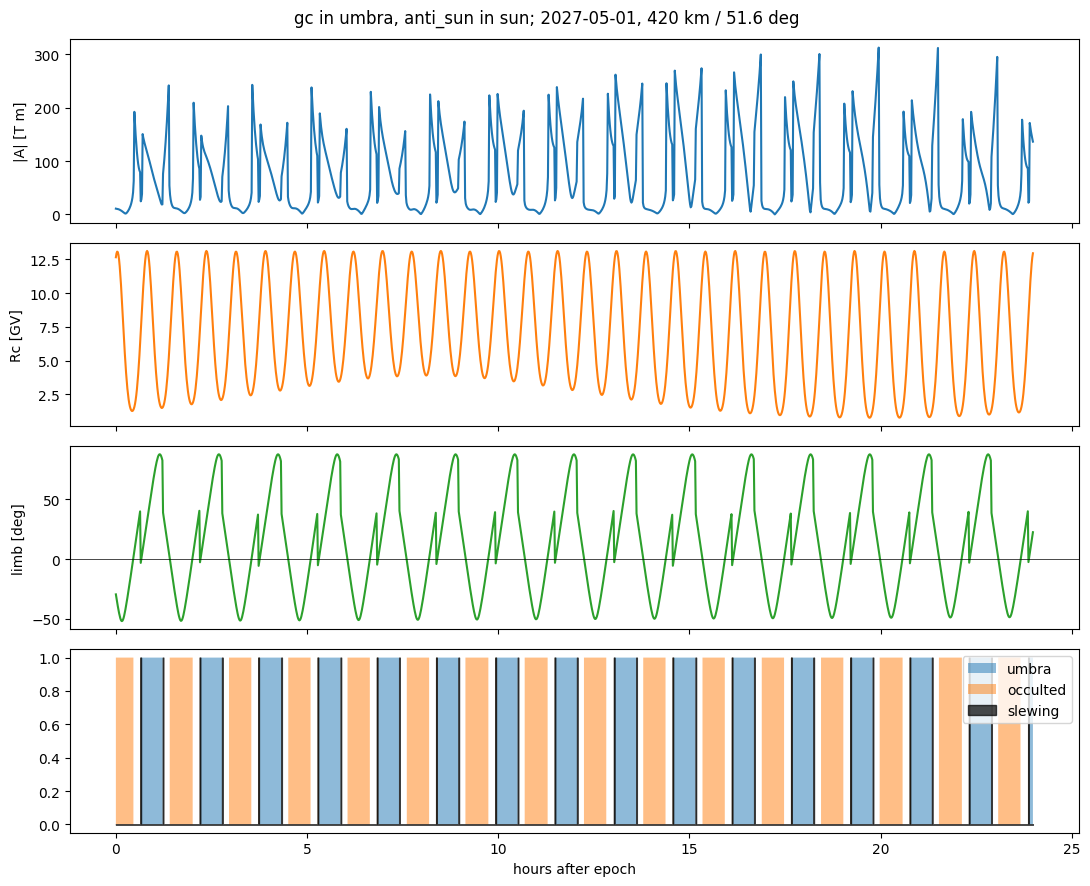

In [5]:
hours = t / 3600
fig, axes = plt.subplots(4, 1, figsize=(11, 9), sharex=True)
axes[0].plot(hours, table["amp_tm"]); axes[0].set_ylabel("|A| [T m]")
axes[1].plot(hours, table["cutoff_gv"], color="C1"); axes[1].set_ylabel("Rc [GV]")
axes[2].plot(hours, table["limb_deg"], color="C2"); axes[2].axhline(0, color="k", lw=0.5)
axes[2].set_ylabel("limb [deg]")
axes[3].fill_between(hours, 0, table["umbra"], step="mid", alpha=0.5, label="umbra")
axes[3].fill_between(hours, 0, table["occulted"], step="mid", alpha=0.5, label="occulted")
axes[3].fill_between(hours, 0, slewing, step="mid", alpha=0.7, color="k", label="slewing")
axes[3].legend(loc="upper right"); axes[3].set_xlabel("hours after epoch")
fig.suptitle(f"{SCIENCE['primary']} in umbra, {SUNLIT['primary']} in sun; {EPOCH[:10]}, {ALT_KM:.0f} km / {INC_DEG} deg")
plt.tight_layout()

## 5. Is the kernel separable from the background proxy?

usable science frames 510  corr(K, Rc) = +0.71  corr(K, limb) = -0.75


Text(0, 0.5, 'K [T^2 m^2]')

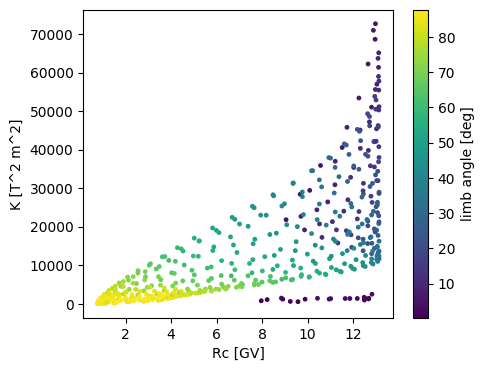

In [6]:
sky = ~table["occulted"] & (mode_index == 0) & ~slewing
rho = np.corrcoef(table["k_t2m2"][sky], table["cutoff_gv"][sky])[0, 1]
rho_limb = np.corrcoef(table["k_t2m2"][sky], table["limb_deg"][sky])[0, 1]
print(f"usable science frames {sky.sum()}  corr(K, Rc) = {rho:+.2f}  corr(K, limb) = {rho_limb:+.2f}")
plt.figure(figsize=(5, 4))
plt.scatter(table["cutoff_gv"][sky], table["k_t2m2"][sky], s=6, c=table["limb_deg"][sky])
plt.colorbar(label="limb angle [deg]"); plt.xlabel("Rc [GV]"); plt.ylabel("K [T^2 m^2]")

## 6. What the boresight sees at one sample

Text(0.5, 1.0, 'gc at +1.1 h, maglat -53, limb 88 deg')

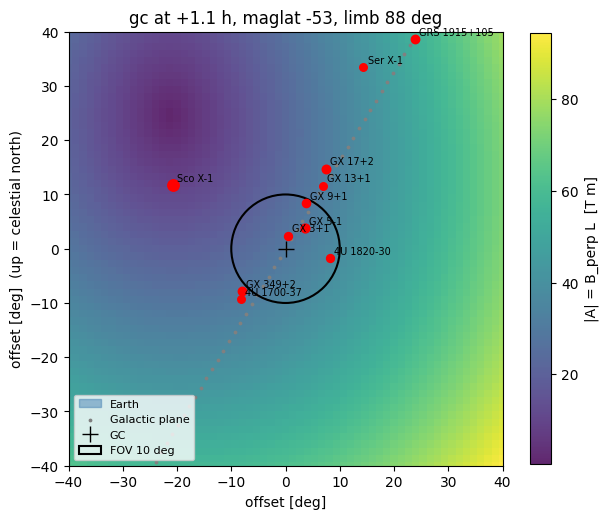

In [7]:
import sys; sys.path.append("../scripts")
from fov_view import fov_view
k = int(np.argmax(np.where(sky, table["limb_deg"], -1e9)))   # highest above the limb
coeffs = field.load_igrf(float(frames.decimal_year(time[k])))
ax = fov_view(r[k], time[k], n[k], coeffs, lmax=LMAX)
ax.set_title(f"{SCIENCE['primary']} at +{t[k]/3600:.1f} h, maglat {table['maglat_deg'][k]:.0f}, limb {table['limb_deg'][k]:.0f} deg")